# Geodesic calculus on groundtruth implicit manifolds
In this notebook we show how to use our geodesic calculus framework on known implicit manifolds with dimension $d$ embedded in $\mathbb{R}^n$. As an example we choose a Torus. The groundtruth implicit representation is implemented in $\phi$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from latentgeodesics import GeodesicSolverNumpy, KExponentialNumpy

We first have to define the implicit representation.

In [2]:
#implicit surface representation of a torus

R = 4/5. #outer radius
r = 0.2 #inner radius

def phi(coord):
    rho = np.sqrt(coord[:, 0]**2 + coord[:, 1]**2)
    return ((rho - R)**2 + coord[:, 2]**2 - r**2).reshape(1, -1)

def dphi(coord):
    rho = np.sqrt(coord[:, 0]**2 + coord[:, 1]**2)
    grad = np.column_stack((
        2 * coord[:, 0] * (rho - R) / rho,
        2 * coord[:, 1] * (rho - R) / rho,
        2 * coord[:, 2]
    ))
    return grad.reshape(1, -1, 3)


In [3]:
# just for plotting the torus
def torus_coordinates(R, r, resolution=100):
    u = np.linspace(0, 2*np.pi, resolution)
    v = np.linspace(0, 2*np.pi, resolution)
    u, v = np.meshgrid(u, v)

    x = (R + r*np.cos(v)) * np.cos(u)
    y = (R + r*np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    
    return x ,y ,z

## Geodesics
Then we can initialize the geodesic solver and compute geodesics between two points xA and xB.

In [4]:
# define solver 
n = 3 # ambient dimension
Solver = GeodesicSolverNumpy(n, phi, dphi)

In [5]:
#choose start and end point that are on the torus
a = np.array([0, 1])
b = np.array([1, 0])

x = (R + r * np.cos(a)) * np.cos(b)
y = (R + r * np.cos(a)) * np.sin(b)
z = r * np.sin(a)

xA, xB = np.column_stack((x, y, z))  

#resolution of the geodesic (number of free points)
K  = 48

In [ ]:
geodesic = Solver.AugLagrangeMinimize(K, xA=xA, xB=xB, alpha=100) #default is alpha=2 but for ground truth functions higher values are safe

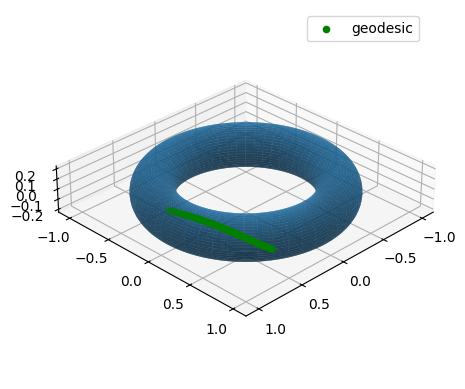

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(*torus_coordinates(R,r),  edgecolor='none', alpha=0.7)
coord = torus_coordinates(R,r)
ax.set_box_aspect([np.ptp(a) for a in coord])
ax.view_init(elev=30, azim=45) 
ax.scatter(geodesic[:,0], geodesic[:,1], geodesic[:,2], color='green', label='geodesic')
ax.legend()

plt.show()

## Exponential

To compute an exponential map, we specify a start point xA and a shooting direction v.
If we choose the start point of the geodsic and v as initial direction of the geodesic we reproduce the geodesic.

In [8]:
xA = geodesic[0]
v = K*(geodesic[1]-geodesic[0])

In [ ]:
exp = KExponentialNumpy(phi, dphi, xA, v, K)

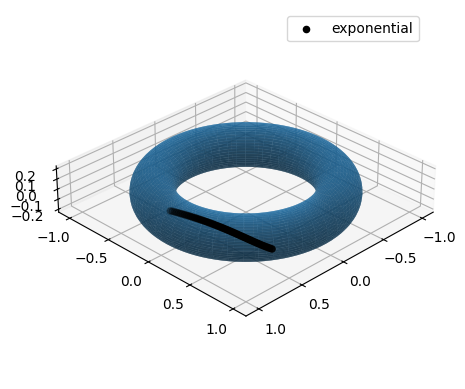

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(*torus_coordinates(R,r),  edgecolor='none', alpha=0.7)
coord = torus_coordinates(R,r)
ax.set_box_aspect([np.ptp(a) for a in coord])
ax.view_init(elev=30, azim=45) 
ax.scatter(exp[:,0], exp[:,1], exp[:,2], color='black', label='exponential')
ax.legend()
plt.show()
